In [1]:
#Import Libraries
import pandas as pd
from matplotlib import pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split

In [3]:
#Load the Data
diabetes = pd.read_csv('diabetes.csv')
diabetes.head()

,PatientID,Pregnancies,PlasmaGlucose,DiastolicBloodPressure,TricepsThickness,SerumInsulin,BMI,DiabetesPedigree,Age,Diabetic
0,1354778,0,171,80,34,23,43.509726,1.213191,21,0
1,1147438,8,92,93,47,36,21.240576,0.158365,23,0
2,1640031,7,115,47,52,35,41.511523,0.079019,23,0
3,1883350,9,103,78,25,304,29.582192,1.282870,43,1
4,1424119,1,85,59,27,35,42.604536,0.549542,22,0


In [4]:
diabetes.describe()

,PatientID,Pregnancies,PlasmaGlucose,DiastolicBloodPressure,TricepsThickness,SerumInsulin,BMI,DiabetesPedigree,Age,Diabetic
count,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,1.502922e+06,3.224533,107.856867,71.220667,28.814000,137.852133,31.509646,0.398968,30.137733,0.333333
std,2.892534e+05,3.391020,31.981975,16.758716,14.555716,133.068252,9.759000,0.377944,12.089703,0.471420
min,1.000038e+06,0.000000,44.000000,24.000000,7.000000,14.000000,18.200512,0.078044,21.000000,0.000000
25%,1.252866e+06,0.000000,84.000000,58.000000,15.000000,39.000000,21.259887,0.137743,22.000000,0.000000
50%,1.505508e+06,2.000000,104.000000,72.000000,31.000000,83.000000,31.767940,0.200297,24.000000,0.000000
75%,1.755205e+06,6.000000,129.000000,85.000000,41.000000,195.000000,39.259692,0.616285,35.000000,1.000000
max,1.999997e+06,14.000000,192.000000,117.000000,93.000000,799.000000,56.034628,2.301594,77.000000,1.000000


In [5]:
#separate the features from the labels - we'll call the features X and the label y:

# Separate features and labels
features = ['Pregnancies','PlasmaGlucose','DiastolicBloodPressure','TricepsThickness','SerumInsulin','BMI','DiabetesPedigree','Age']
label = 'Diabetic'
X, y = diabetes[features].values, diabetes[label].values

for n in range(0,4):
    print(f"Patient {str(n+1)}, \n  Features: {list(X[n])} \n  Label: {y[n]}")

Patient 1, 
  Features: [0.0, 171.0, 80.0, 34.0, 23.0, 43.50972593, 1.213191354, 21.0] 
  Label: 0
Patient 2, 
  Features: [8.0, 92.0, 93.0, 47.0, 36.0, 21.24057571, 0.158364981, 23.0] 
  Label: 0
Patient 3, 
  Features: [7.0, 115.0, 47.0, 52.0, 35.0, 41.51152348, 0.079018568, 23.0] 
  Label: 0
Patient 4, 
  Features: [9.0, 103.0, 78.0, 25.0, 304.0, 29.58219193, 1.282869847, 43.0] 
  Label: 1


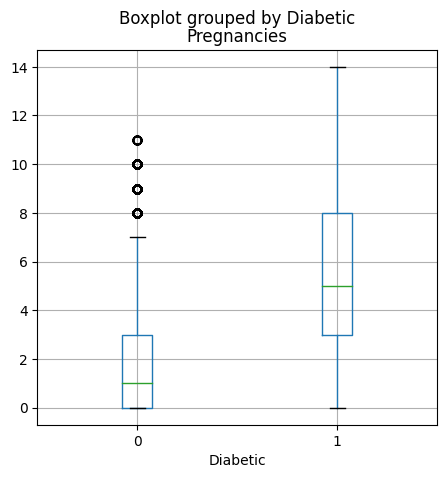

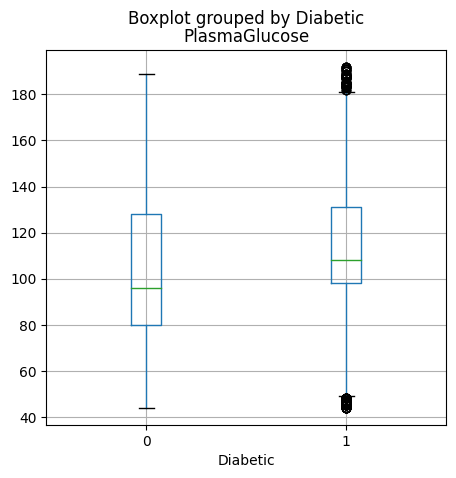

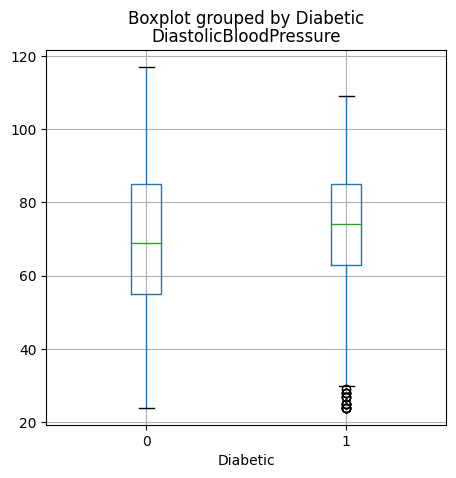

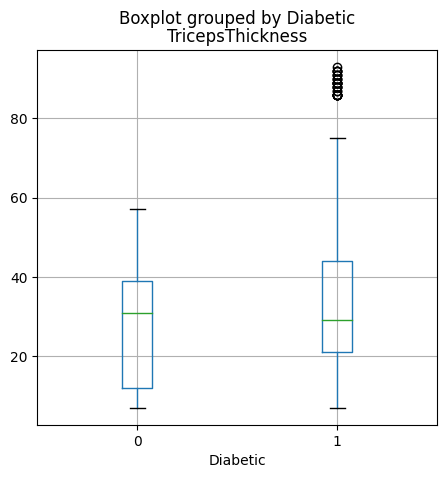

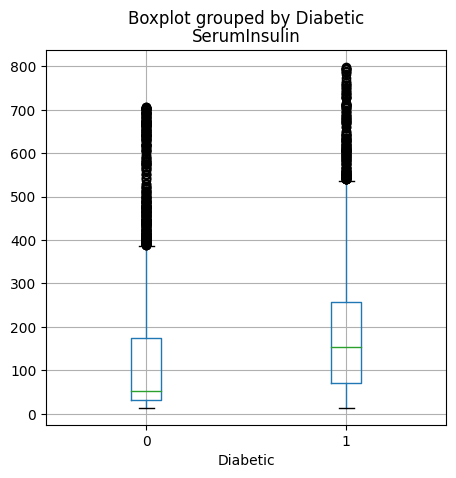

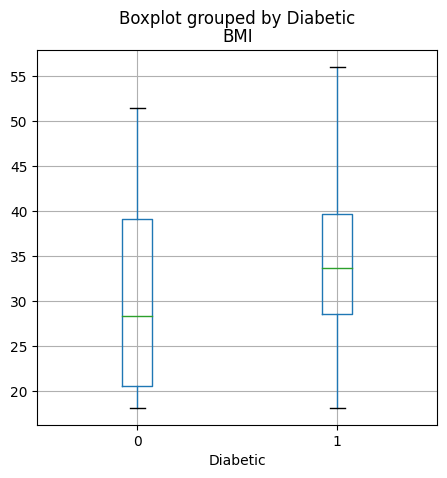

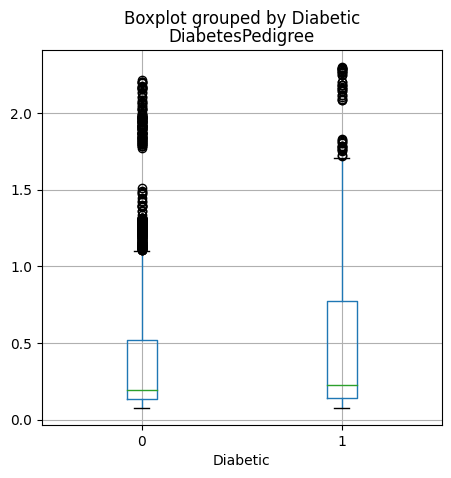

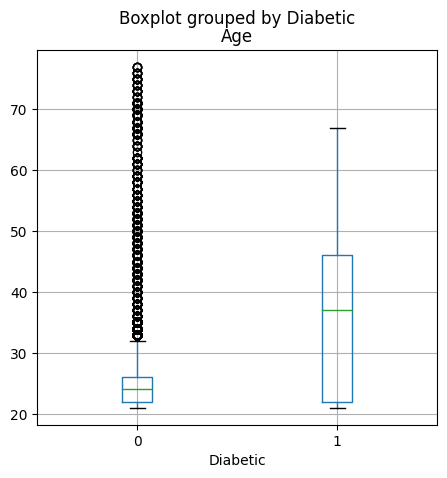

In [9]:
 #let's compare the feature distributions for each label value.

features = ['Pregnancies','PlasmaGlucose','DiastolicBloodPressure','TricepsThickness','SerumInsulin','BMI','DiabetesPedigree','Age']
for col in features:
    diabetes.boxplot(column=col, by='Diabetic', figsize=(5,5))
    plt.title(col)
plt.show()

In [10]:
# Split data 70%-30% into training set and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.3, random_state= 0)
print (f'X_train: {X_train.shape} \nX_test: {X_test.shape} \ny_train: {y_train.shape} \ny_test: {y_test.shape}')

X_train: (10500, 8) 
X_test: (4500, 8) 
y_train: (10500,) 
y_test: (4500,)


In [11]:
# Train the model
from sklearn.linear_model import LogisticRegression

# Set regularization rate
reg = 0.01

# train a logistic regression model on the training set
model = LogisticRegression(C=1/reg, solver="liblinear").fit(X_train, y_train)
print (model)

LogisticRegression(C=100.0, solver='liblinear')


In [12]:
predictions = model.predict(X_test)
print('Predicted labels: ', predictions)
print('Actual labels:    ' ,y_test)

Predicted labels:  [0 0 0 ... 0 1 0]
Actual labels:     [0 0 1 ... 1 1 1]


In [13]:
from sklearn.metrics import accuracy_score

print(f"Accuracy score: {accuracy_score(y_test, predictions)}")

Accuracy score: 0.7893333333333333


In [14]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.81      0.88      0.85      2986
           1       0.72      0.60      0.66      1514

    accuracy                           0.79      4500
   macro avg       0.77      0.74      0.75      4500
weighted avg       0.78      0.79      0.78      4500



In [15]:
#Precision: Of the predictons the model made for this class, what proportion were correct?
#Recall: Out of all of the instances of this class in the test dataset, how many did the model identify?
#F1-Score: An average metric that takes both precision and recall into account.
#Support: How many instances of this class are there in the test dataset?

In [17]:
#The classification report also includes averages for these metrics, including a weighted average that allows for the imbalance in the number of cases of each class.

#Because this is a binary classification problem, the 1 class is considered positive and its precision and recall are particularly interesting - these in effect answer the questions:

#Of all the patients the model predicted are diabetic, how many are actually diabetic?
#Of all the patients that are actually diabetic, how many did the model identify? You can retrieve these values on their own by using the precision_score and recall_score metrics in scikit-learn (which by default assume a binary classification model).


In [18]:
from sklearn.metrics import precision_score, recall_score

print("Overall Precision:",precision_score(y_test, predictions))
print("Overall Recall:",recall_score(y_test, predictions))

Overall Precision: 0.7242472266244057
Overall Recall: 0.6036988110964333


In [19]:
from sklearn.metrics import confusion_matrix

# Print the confusion matrix
cm = confusion_matrix(y_test, predictions)
print (cm)

[[2638  348]
 [ 600  914]]


In [20]:
#we've considered the predictions from the model as being either 1 or 0 class labels. 
#Actually, things are a little more complex than that. 
#Statistical machine learning algorithms, like logistic regression, are based on probability; 
#so what actually gets predicted by a binary classifier is 
#the probability that the label is true (P(y))and the probability that the label is false (1 - P(y)).
#A threshold value of 0.5 is used to decide whether 
#the predicted label is a 1 (P(y) > 0.5) or a 0 (P(y) <= 0.5). 
#You can use the predict_proba method to see the probability pairs for each case:

In [21]:
y_scores = model.predict_proba(X_test)
print(y_scores)

[[0.81651727 0.18348273]
 [0.96298333 0.03701667]
 [0.80862083 0.19137917]
 ...
 [0.60688422 0.39311578]
 [0.10672996 0.89327004]
 [0.63865894 0.36134106]]


In [22]:
#The decision to score a prediction as a 1 or a 0 depends on the threshold 
#to which the predicted probabilties are compared. 
#If we were to change the threshold, it would affect the predictions; 
#and therefore change the metrics in the confusion matrix.
#A common way to evaluate a classifier is to examine the true positive rate (which is another name for recall)
#and the false positive rate for a range of possible thresholds.
#These rates are then plotted against all possible thresholds
#to form a chart known as a received operator characteristic (ROC) chart

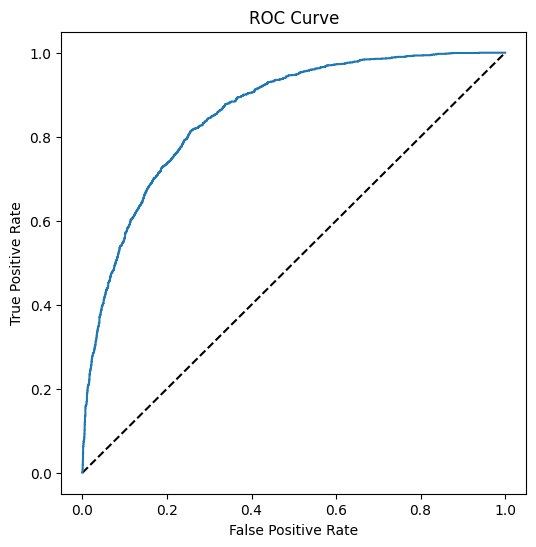

In [23]:
from sklearn.metrics import roc_curve
from sklearn.metrics import confusion_matrix

# calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_scores[:,1])

# plot ROC curve
fig = plt.figure(figsize=(6, 6))
# Plot the diagonal 50% line
plt.plot([0, 1], [0, 1], 'k--')
# Plot the FPR and TPR achieved by our model
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

In [24]:
#The ROC chart shows the curve of the true and false positive rates 
#for different threshold values between 0 and 1.
#A perfect classifier would have a curve that goes straight up the left side and straight across the top. 
#The diagonal line across the chart represents the probability 
#of predicting correctly with a 50/50 random prediction; 
#so you obviously want the curve to be higher than that (or your model is no better than simply guessing!).

#The area under the curve (AUC) is a value between 0 and 1 that quantifies the overall performance of the model.
#The closer to 1 this value is, the better the model. 
#Once again, scikit-Learn includes a function to calculate this metric.

In [25]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test,y_scores[:,1])
print('AUC: ' + str(auc))

AUC: 0.8568482508863468


In [26]:
#Binary classification techniques work well when the data observations belong to one of two classes 
#or categories, such as "True" or "False".When the data can be categorized into more than two classes, 
#you must use a multiclass classification algorithm.
#Multiclass classification can be thought of as a combination of multiple binary classifiers. 
#There are two ways in which you approach the problem:
#One vs Rest (OVR), in which a classifier is created for each possible class value, 
#with a positive outcome for cases where the prediction is this class, 
#and negative predictions for cases where the prediction is any other class. 
#A classification problem with four possible shape classes (square, circle, triangle, hexagon) 
#would require four classifiers that predict:

#square or not
#circle or not
#triangle or not
#hexagon or not
#One vs One (OVO), in which a classifier for each possible pair of classes is created. 
#The classification problem with four shape classes would require the following binary classifiers:

#square or circle
#square or triangle
#square or hexagon
#circle or triangle
#circle or hexagon
#triangle or hexagon 

#In both approaches, the overall model that combines the classifiers generates a vector of predictions 
#in which the probabilities generated from the individual binary classifiers are used 
#to determine which class to predict.
#Fortunately, in most machine learning frameworks, including scikit-learn, 
#implementing a multiclass classification model is not significantly more complex than binary classification - 
#and in most cases, the estimators used for binary classification implicitly support multiclass classification
#by abstracting an OVR algorithm, an OVO algorithm, or by allowing a choice of either.

In [28]:
# load the training dataset
penguins = pd.read_csv('penguins.csv')

# Display a random sample of 10 observations
sample = penguins.sample(10)

print(f"Shape of data: {sample.shape}")
sample

Shape of data: (10, 5)


,CulmenLength,CulmenDepth,FlipperLength,BodyMass,Species
70,33.5,19.0,190.0,3600.0,0
280,52.7,19.8,197.0,3725.0,2
132,36.8,18.5,193.0,3500.0,0
209,45.5,15.0,220.0,5000.0,1
315,53.5,19.9,205.0,4500.0,2
230,45.2,13.8,215.0,4750.0,1
271,NaN,NaN,NaN,NaN,1
254,47.2,15.5,215.0,4975.0,1
44,37.0,16.9,185.0,3000.0,0
86,36.3,19.5,190.0,3800.0,0


In [29]:
#The dataset contains the following columns:

#CulmenLength: The length in mm of the penguin's culmen (bill).
#CulmenDepth: The depth in mm of the penguin's culmen.
#FlipperLength: The length in mm of the penguin's flipper.
#BodyMass: The body mass of the penguin in grams.
#Species: An integer value that represents the species of the penguin.
#The Species column is the label we want to train a model to predict. 
#The dataset includes three possible species, which are encoded as 0, 1, and 2.
#The actual species names are revealed by the code below:

In [30]:
penguin_classes = ['Amelie', 'Gentoo', 'Chinstrap']
print(sample.columns[0:5].values, 'SpeciesName')
for index, row in penguins.sample(10).iterrows():
    print('[',row[0], row[1], row[2], row[3], int(row[4]),']',penguin_classes[int(row[4])])

['CulmenLength' 'CulmenDepth' 'FlipperLength' 'BodyMass' 'Species'] SpeciesName
[ 36.6 18.4 184.0 3475.0 0 ] Amelie
[ 46.5 17.9 192.0 3500.0 2 ] Chinstrap
[ 40.2 20.1 200.0 3975.0 0 ] Amelie
[ 42.2 18.5 180.0 3550.0 0 ] Amelie
[ 37.7 19.8 198.0 3500.0 0 ] Amelie
[ 35.5 16.2 195.0 3350.0 0 ] Amelie
[ 48.1 16.4 199.0 3325.0 2 ] Chinstrap
[ 37.5 18.5 199.0 4475.0 0 ] Amelie
[ 47.7 15.0 216.0 4750.0 1 ] Gentoo
[ 46.5 13.5 210.0 4550.0 1 ] Gentoo


In [31]:
#let's explore the dataset. First,
#let's see if there are any missing (null) values

# Count the number of null values for each column
penguins.isnull().sum()

CulmenLength     2
CulmenDepth      2
FlipperLength    2
BodyMass         2
Species          0
dtype: int64

In [32]:
# Show rows containing nulls
penguins[penguins.isnull().any(axis=1)]

,CulmenLength,CulmenDepth,FlipperLength,BodyMass,Species
3,NaN,NaN,NaN,NaN,0
271,NaN,NaN,NaN,NaN,1


In [34]:
#There are two rows that contain no feature values at all (NaN stands for "not a number"), 
#so these won't be useful in training a model. Let's discard them from the dataset.

# Drop rows containing NaN values
penguins=penguins.dropna()
#Confirm there are now no nulls
penguins.isnull().sum()

CulmenLength     0
CulmenDepth      0
FlipperLength    0
BodyMass         0
Species          0
dtype: int64

In [35]:
#Now that we've dealt with the missing values, 
#let's explore how the features relate to the label by creating some box charts.

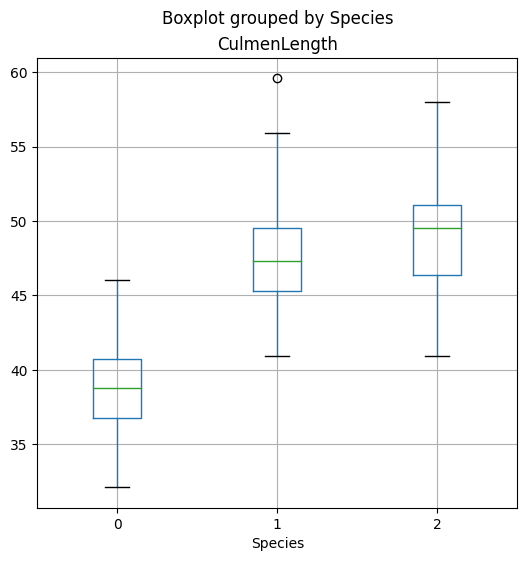

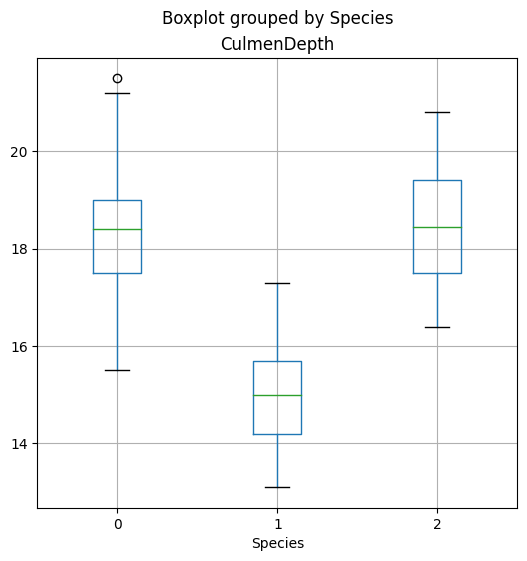

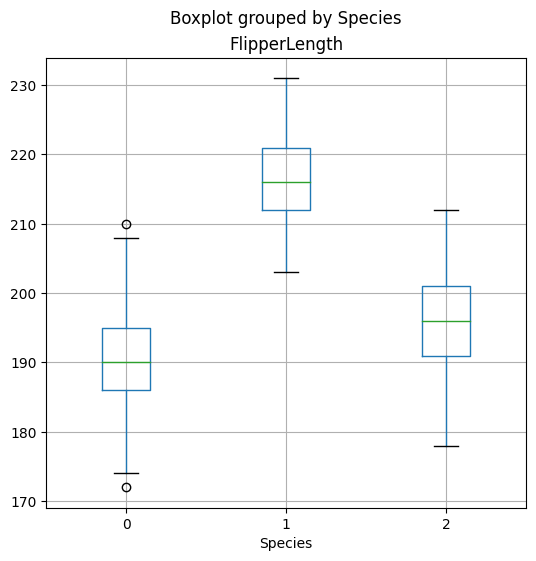

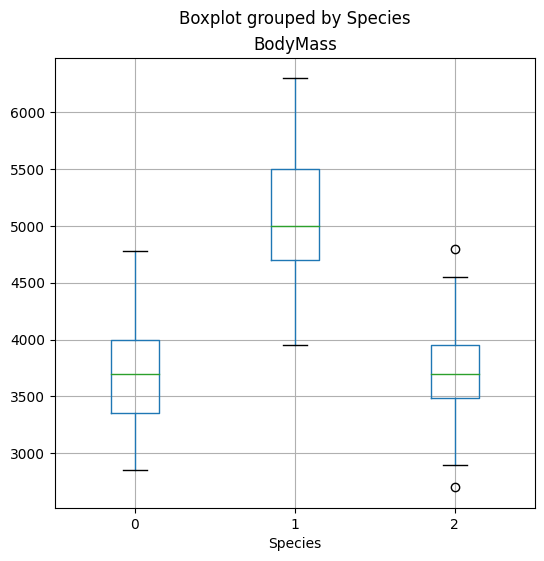

In [36]:
penguin_features = ['CulmenLength','CulmenDepth','FlipperLength','BodyMass']
penguin_label = 'Species'
for col in penguin_features:
    penguins.boxplot(column=col, by=penguin_label, figsize=(6,6))
    plt.title(col)
plt.show()

In [37]:
#Prepare the data
#As for binary classification, before training the model, 
#we need to separate the features and label, 
#and then split the data into subsets for training and validation. 
#We'll also apply a stratification technique when splitting the data 
#to maintain the proportion of each label value in the training and validation datasets.

In [38]:
# Separate features and labels
penguins_X, penguins_y = penguins[penguin_features].values, penguins[penguin_label].values

# Split data 70%-30% into training set and test set
x_penguin_train, x_penguin_test, y_penguin_train, y_penguin_test = train_test_split(penguins_X, penguins_y,
                                                                                    test_size=0.30,
                                                                                    random_state=0,
                                                                                    stratify=penguins_y)

print ('Training Set: %d, Test Set: %d \n' % (x_penguin_train.size, x_penguin_test.size))

Training Set: 956, Test Set: 412 



In [39]:
#Train and evaluate a multiclass classifier
#Now that we have a set of training features and corresponding training labels, 
#we can fit a multiclass classification algorithm to the data to create a model.
#Most scikit-learn classification algorithms inherently support multiclass classification. 
#We'll try a logistic regression algorithm.

In [40]:
from sklearn.linear_model import LogisticRegression

# Set regularization rate
reg = 0.1

# train a logistic regression model on the training set
multi_model = LogisticRegression(C=1/reg, solver='lbfgs', multi_class='auto', max_iter=10000).fit(x_penguin_train, y_penguin_train)
print (multi_model)

LogisticRegression(C=10.0, max_iter=10000)


In [41]:
#Now we can use the trained model to predict the labels for the test features, 
#and compare the predicted labels to the actual labels:

In [42]:
penguin_predictions = multi_model.predict(x_penguin_test)
print('Predicted labels: ', penguin_predictions[:15])
print('Actual labels   : ' ,y_penguin_test[:15])

Predicted labels:  [0 1 0 2 2 1 1 1 0 2 2 1 2 1 2]
Actual labels   :  [0 1 2 2 2 1 1 1 0 2 2 1 2 1 2]


In [43]:
#classification report.

from sklearn. metrics import classification_report

print(classification_report(y_penguin_test, penguin_predictions))

              precision    recall  f1-score   support

           0       0.96      0.98      0.97        45
           1       1.00      1.00      1.00        37
           2       0.95      0.90      0.93        21

    accuracy                           0.97       103
   macro avg       0.97      0.96      0.96       103
weighted avg       0.97      0.97      0.97       103



In [44]:
#with binary classification, the report includes precision and recall metrics for each class. 
#However, while with binary classification we could focus on the scores for the positive class; 
#in this case, there are multiple classes so we need to look at an overall metric 
#(either the macro or weighted average) to get a sense of how well the model performs across all three classes.

#You can get the overall metrics separately from the report using the scikit-learn metrics score classes, 
#but with multiclass results you must specify which average metric you want to use for precision and recall.

#macro average: The function to compute f1 for each label, 
#and returns the average without considering the proportion for each label in the dataset.
#weighted average: The function to compute f1 for each label, 
#and returns the average considering the proportion for each label in the dataset.

In [45]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

print("Overall Accuracy:",accuracy_score(y_penguin_test, penguin_predictions))
print("Overall Precision:",precision_score(y_penguin_test, penguin_predictions, average='macro'))
print("Overall Recall:",recall_score(y_penguin_test, penguin_predictions, average='macro'))

Overall Accuracy: 0.970873786407767
Overall Precision: 0.9688405797101449
Overall Recall: 0.9608465608465608


In [46]:
# Print the confusion matrix
mcm = confusion_matrix(y_penguin_test, penguin_predictions)
print(mcm)

[[44  0  1]
 [ 0 37  0]
 [ 2  0 19]]


In [47]:
#The confusion matrix shows the intersection of predicted and actual label values for each class - 
#in simple terms, the diagonal intersections from top-left to bottom-right indicate the number of 
#correct predictions.

#When dealing with multiple classes, it's generally more intuitive to visualize this as a heat map, like this:

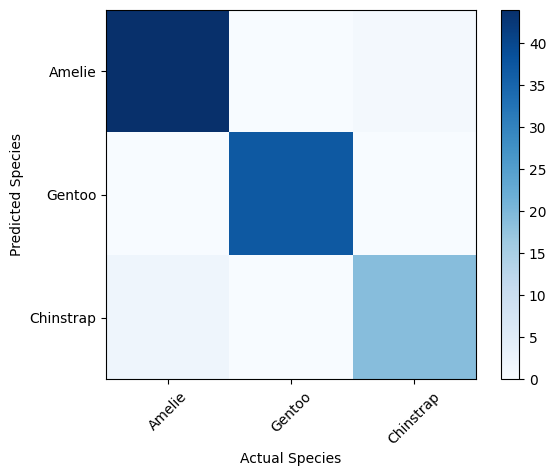

In [49]:
import numpy as np
plt.imshow(mcm, interpolation="nearest", cmap=plt.cm.Blues)
plt.colorbar()
tick_marks = np.arange(len(penguin_classes))
plt.xticks(tick_marks, penguin_classes, rotation=45)
plt.yticks(tick_marks, penguin_classes)
plt.xlabel("Actual Species")
plt.ylabel("Predicted Species")
plt.show()

In [50]:
#The darker squares in the confusion matrix plot indicate high numbers of cases, 
#and you can hopefully see a diagonal line of darker squares indicating cases 
#where the predicted and actual label are the same.

#In the case of a multiclass classification model,
#a single ROC curve showing true positive rate vs false positive rate is not possible. 
#However, you can use the rates for each class in a One vs Rest (OVR) 
#comparison to create a ROC chart for each class.

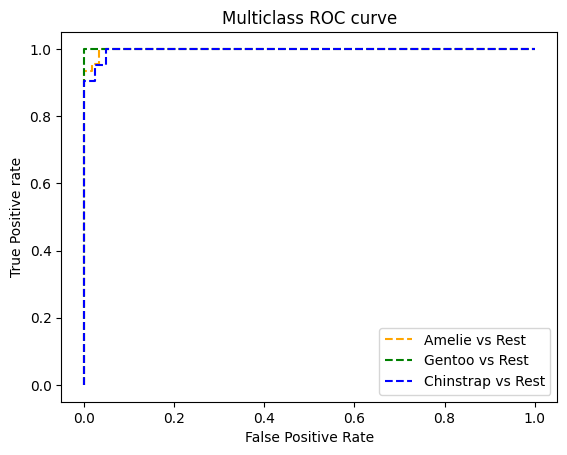

In [51]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

# Get class probability scores
penguin_prob = multi_model.predict_proba(x_penguin_test)

# Get ROC metrics for each class
fpr = {}
tpr = {}
thresh ={}
for i in range(len(penguin_classes)):    
    fpr[i], tpr[i], thresh[i] = roc_curve(y_penguin_test, penguin_prob[:,i], pos_label=i)
    
# Plot the ROC chart
plt.plot(fpr[0], tpr[0], linestyle='--',color='orange', label=penguin_classes[0] + ' vs Rest')
plt.plot(fpr[1], tpr[1], linestyle='--',color='green', label=penguin_classes[1] + ' vs Rest')
plt.plot(fpr[2], tpr[2], linestyle='--',color='blue', label=penguin_classes[2] + ' vs Rest')
plt.title('Multiclass ROC curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive rate')
plt.legend(loc='best')
plt.show()

In [52]:
#To quantify the ROC performance, you can calculate an aggregate area under the curve score that 
#is averaged across all of the OVR curves.

In [53]:
auc = roc_auc_score(y_penguin_test,penguin_prob, multi_class='ovr')
print('Average AUC:', auc)

Average AUC: 0.9981999902100828
